В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [11]:
cars_df = pd.read_csv('cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [12]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

Signature:
pd.DataFrame.info(
    self,
    verbose: 'bool | None' = None,
    buf: 'WriteBuffer[str] | None' = None,
    max_cols: 'int | None' = None,
    memory_usage: 'bool | str | None' = None,
    show_counts: 'bool | None' = None,
    null_counts: 'bool | None' = None,
) -> 'None'
Docstring:
Print a concise summary of a DataFrame.

This method prints information about a DataFrame including
the index dtype and columns, non-null values and memory usage.

Parameters
----------
data : DataFrame
    DataFrame to print information about.
verbose : bool, optional
    Whether to print the full summary. By default, the setting in
    ``pandas.options.display.max_info_columns`` is followed.
buf : writable buffer, defaults to sys.stdout
    Where to send the output. By default, the output is printed to
    sys.stdout. Pass a writable buffer if you need to further process
    the output.    max_cols : int, optional
    When to switch from the verbose to the truncated output. If the
    Data

In [37]:
print(cars_df.dtypes)
print(cars_df.info())


Car_ID                int64
Brand                object
Model                object
Year                  int64
Kilometers_Driven     int64
Fuel_Type            object
Transmission         object
Owner_Type           object
Mileage               int64
Engine                int64
Power                 int64
Seats                 int64
Price                 int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 

In [38]:
numeric_cols = cars_df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['Car_ID', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power',
       'Seats', 'Price'],
      dtype='object')


In [39]:
categorical_cols = cars_df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')


In [40]:
cars_df[categorical_cols].nunique()

Brand           11
Model           58
Fuel_Type        2
Transmission     2
Owner_Type       3
dtype: int64

In [41]:
binary_cols = [col for col in categorical_cols if cars_df[col].nunique() == 2]

In [42]:
binary_cols

['Fuel_Type', 'Transmission']

In [43]:
multi_cols = [col for col in categorical_cols if cars_df[col].nunique() > 2]
print(multi_cols)

['Brand', 'Model', 'Owner_Type']


In [44]:
print("Brand: ", cars_df.Brand.unique())
print("Model: ", cars_df.Model.unique())
print("Owner_Type: ", cars_df.Owner_Type.unique())

Brand:  ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']
Model:  ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']
Owner_Type:  ['First' 'Second' 'Third']


In [21]:
print(f"В наборі даних {len(numeric_cols)} числових і {len(categorical_cols)} категоріальних колонок, з них: ")
print(f"- {len(binary_cols)} бінарні")
print("- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку")
print("- 1 колонкa, в яких можна встановити відношення порядку (First, Second, Third))")

В наборі даних 8 числових і 5 категоріальних колонок, з них: 
- 2 бінарні
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 1 колонкa, в яких можна встановити відношення порядку (First, Second, Third))


**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [22]:
# Визначаємо вхідні дані і таргет
inputs = cars_df.drop(columns=['Price'])
targets = cars_df['Price']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=12)

In [24]:
y_train

83    1600000
55    2600000
26    3200000
54     650000
19    2500000
       ...   
3      600000
2     2500000
6      900000
27    2800000
75    3500000
Name: Price, Length: 80, dtype: int64

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [46]:
fuel_type_codes = {'Petrol': 0, 'Diesel': 1}
transmission_codes = {'Manual': 0, 'Automatic': 1}

In [47]:
X_train['fuel_type_code'] = X_train.Fuel_Type.map(fuel_type_codes)
X_train['transmission_code'] = X_train.Transmission.map(transmission_codes)

In [48]:
X_test['fuel_type_code'] = X_test.Fuel_Type.map(fuel_type_codes)
X_test['transmission_code'] = X_test.Transmission.map(transmission_codes)

In [49]:
X_train.head(), X_test.head()

(    Car_ID       Brand  Model  Year  Kilometers_Driven Fuel_Type Transmission  \
 83      84  Volkswagen  T-Roc  2019              22000    Petrol    Automatic   
 55      56        Audi     A5  2018              28000    Diesel    Automatic   
 26      27        Audi     A6  2018              28000    Petrol    Automatic   
 54      55  Volkswagen  Vento  2017              32000    Petrol       Manual   
 19      20    Mercedes    GLC  2017              26000    Petrol    Automatic   
 
    Owner_Type  Mileage  Engine  Power  Seats  fuel_type_code  \
 83     Second       18    1498    148      5               0   
 55      First       17    1968    187      5               1   
 26      First       15    1984    241      5               0   
 54     Second       18    1598    103      5               0   
 19     Second       12    1991    241      5               0   
 
     transmission_code  Owner_Type_Codes  
 83                  1               1.0  
 55                  1      

In [50]:
from sklearn import preprocessing
encoder = preprocessing.OneHotEncoder()



In [51]:
encoder.fit(X_train[['Brand']])
encoder.transform(X_train[['Brand']])
encoder.transform(X_test[['Brand']])

<20x11 sparse matrix of type '<class 'numpy.float64'>'
	with 20 stored elements in Compressed Sparse Row format>

In [52]:
encoder.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [53]:
one_hot_train = encoder.transform(X_train[['Brand']]).toarray()
one_hot_test = encoder.transform(X_test[['Brand']]).toarray()

In [57]:
brand_cols = encoder.get_feature_names_out(['Brand'])

In [58]:
one_hot_train_df = pd.DataFrame(one_hot_train, columns=brand_cols, index=X_train.index)
one_hot_test_df = pd.DataFrame(one_hot_test, columns=brand_cols, index=X_test.index)

X_train = pd.concat([X_train, one_hot_train_df], axis=1)
X_test = pd.concat([X_test, one_hot_test_df], axis=1)

In [55]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [59]:
X_test.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_code,transmission_code,Owner_Type_Codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,0,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0,0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0,0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_code,transmission_code,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0,1,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1,1,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,0,1,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0,1,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_code,transmission_code,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,0,1,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0,0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0,0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0,0,2.0


(None, None)

Очікуваний результат після трансформацій:

In [ ]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [60]:
X_train = X_train.select_dtypes(include=['number'])

In [61]:
corr_X_y = pd.concat([X_train, y_train], axis=1)

In [62]:
corr_matrix = corr_X_y.corr()

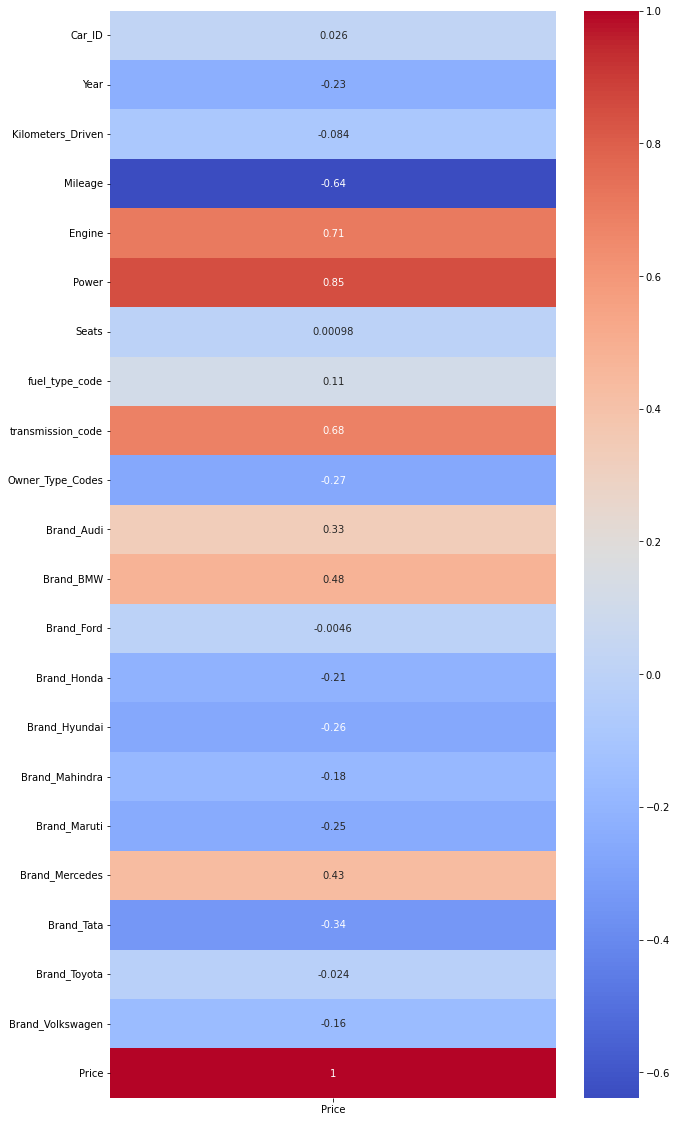

In [63]:
plt.figure(figsize=(10,20))
sns.heatmap(corr_matrix[["Price"]], annot=True, cmap='coolwarm')
plt.show()

In [64]:
X_train.columns.value_counts()

Car_ID               1
Brand_BMW            1
Brand_Toyota         1
Brand_Tata           1
Brand_Mercedes       1
Brand_Maruti         1
Brand_Mahindra       1
Brand_Hyundai        1
Brand_Honda          1
Brand_Ford           1
Brand_Audi           1
Year                 1
Owner_Type_Codes     1
transmission_code    1
fuel_type_code       1
Seats                1
Power                1
Engine               1
Mileage              1
Kilometers_Driven    1
Brand_Volkswagen     1
dtype: int64

### Найбільшу кореляцію з цільовою змінною Price мають ознаки Power (0.85), Engine (0.71), Transmission_Code (0.68) та Mileage (-0.64). Перші 3 позитивно корелюють з ціною, a Mileage має сильну негативну кореляцію.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [65]:
X_test = X_test.select_dtypes(include=['number'])

In [66]:
X_train.dtypes, X_test.dtypes

(Car_ID                 int64
 Year                   int64
 Kilometers_Driven      int64
 Mileage                int64
 Engine                 int64
 Power                  int64
 Seats                  int64
 fuel_type_code         int64
 transmission_code      int64
 Owner_Type_Codes     float64
 Brand_Audi           float64
 Brand_BMW            float64
 Brand_Ford           float64
 Brand_Honda          float64
 Brand_Hyundai        float64
 Brand_Mahindra       float64
 Brand_Maruti         float64
 Brand_Mercedes       float64
 Brand_Tata           float64
 Brand_Toyota         float64
 Brand_Volkswagen     float64
 dtype: object,
 Car_ID                 int64
 Year                   int64
 Kilometers_Driven      int64
 Mileage                int64
 Engine                 int64
 Power                  int64
 Seats                  int64
 fuel_type_code         int64
 transmission_code      int64
 Owner_Type_Codes     float64
 Brand_Audi           float64
 Brand_BMW            fl

In [67]:
model = LinearRegression()
model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_rmse = mean_squared_error(y_train, train_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_predictions, squared=False)

print('тренувальні дані RMSE:', train_rmse)
print('тестові дані RMSE:', test_rmse)

тренувальні дані RMSE: 210293.5782815183
тестові дані RMSE: 258181.56112032724


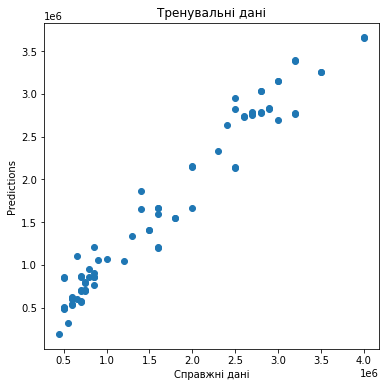

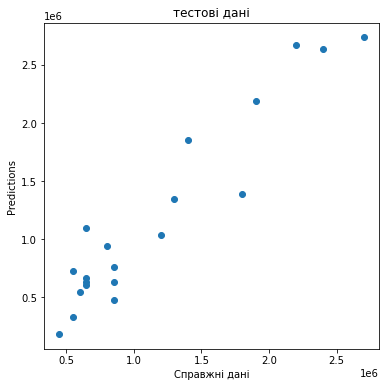

In [68]:
plt.figure(figsize=(6,6))
plt.scatter(y_train, train_predictions)

plt.xlabel('Cправжні дані')
plt.ylabel('Predictions')
plt.title('Tренувальні дані')
plt.show()

# Testdaten
plt.figure(figsize=(6,6))
plt.scatter(y_test, test_predictions)
plt.xlabel('Cправжні дані')
plt.ylabel('Predictions')
plt.title('тестові дані')
plt.show()

### На графіках видно, що передбачені значення мають позитивну лінійну залежність з реальними значеннями таргету. Точки розташовані досить близько до уявної прямої; присутні відхилення. Значення RMSE на тестовому наборі трохи більше, ніж на тренувальному.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [69]:
from sklearn.preprocessing import StandardScaler

In [70]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [73]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
X_train_scaled

array([[ 1.09092769,  0.56881254, -0.69387081, ..., -0.37796447,
        -0.33333333,  3.22932987],
       [ 0.10038127, -0.32344242, -0.03953291, ..., -0.37796447,
        -0.33333333, -0.30966177],
       [-0.92554181, -0.32344242, -0.03953291, ..., -0.37796447,
        -0.33333333, -0.30966177],
       ...,
       [-1.63307497, -0.32344242,  1.81442446, ..., -0.37796447,
        -0.33333333, -0.30966177],
       [-0.89016515,  0.56881254, -0.69387081, ..., -0.37796447,
        -0.33333333, -0.30966177],
       [ 0.80791442,  0.56881254, -0.69387081, ..., -0.37796447,
        -0.33333333, -0.30966177]])

In [75]:
X_test_scaled

array([[-1.24393173, -2.10795235,  1.05103025, -0.60469588, -0.78533317,
        -0.23196684, -0.30356247, -0.97530483,  0.79539491,  0.53530338,
         3.        , -0.3560345 , -0.3560345 , -0.25819889, -0.2847474 ,
        -0.22941573, -0.25819889, -0.3560345 , -0.37796447, -0.33333333,
        -0.30966177],
       [-0.39489194,  0.56881254, -0.25764555,  0.86123353, -1.25585925,
        -1.21448688, -0.30356247, -0.97530483, -1.25723711,  2.0647416 ,
        -0.33333333, -0.3560345 , -0.3560345 , -0.25819889,  3.51188458,
        -0.22941573, -0.25819889, -0.3560345 , -0.37796447, -0.33333333,
        -0.30966177],
       [ 1.40931761, -1.21569739,  0.39669235,  0.27486176, -0.47621732,
        -0.78463436, -0.30356247, -0.97530483, -1.25723711,  0.53530338,
        -0.33333333, -0.3560345 , -0.3560345 , -0.25819889, -0.2847474 ,
        -0.22941573, -0.25819889, -0.3560345 , -0.37796447, -0.33333333,
         3.22932987],
       [-1.35006171,  1.4610675 , -1.13009608,  0.56804765

In [81]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

LinearRegression()

In [82]:
model_scaled.coef_

array([   5608.68542149,   -8765.64571392,  -94398.72148597,
       -131715.51202972,  -21377.45333789,  496769.21489874,
         -2148.92454899,  183848.01890892,  116693.76820576,
         42344.95281544,  205600.14776875,  208407.31378257,
       -118209.45031066,  -62753.005386  , -152304.86391146,
       -140945.16290405, -112259.96701985,  210048.78114763,
        -65996.24697212,   15805.70151142,  -92968.2600652 ])

In [86]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_scaled.coef_
})

coef_df.sort_values(by = "Coefficient")

,Feature,Coefficient
14,Brand_Hyundai,-152304.863911
15,Brand_Mahindra,-140945.162904
3,Mileage,-131715.512030
12,Brand_Ford,-118209.450311
16,Brand_Maruti,-112259.967020
2,Kilometers_Driven,-94398.721486
20,Brand_Volkswagen,-92968.260065
18,Brand_Tata,-65996.246972
13,Brand_Honda,-62753.005386
4,Engine,-21377.453338


### Найбільший позитивний вплив на цільову змінну має ознака Power: потужніші автомобілі зазвичай коштують дорожче. Також позитивний вплив мають ознаки Brand_Mercedes, Brand_BMW та Brand_Audi, що відповідає тому, що автомобілі цих марок зазвичай мають вищу ціну.

Негативний вплив мають ознаки Mileage та Kilometers_Driven, Brand_Hyundai, Brand_Mahindra, Brand_Maruti та Brand_Ford: автомобілі цих марок у середньому мають нижчу вартість порівняно з базовою категорією.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [107]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)

model_sm = sm.OLS(y_train, X_train_sm)
results = model_sm.fit()

In [111]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           2.01e-33
Time:                        13:36:23   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.68e+06   2.74e+04     61.363      0.0

In [114]:
results.pvalues

const    3.734558e-55
x1       8.685654e-01
x2       8.860405e-01
x3       1.525755e-01
x4       2.760048e-02
x5       7.703140e-01
x6       1.343837e-08
x7       9.595569e-01
x8       1.639420e-04
x9       1.022962e-02
x10      3.762199e-01
x11      7.485851e-09
x12      1.669757e-08
x13      8.736558e-04
x14      7.299393e-02
x15      2.204650e-06
x16      1.354686e-05
x17      2.875539e-04
x18      9.320195e-09
x19      9.977434e-02
x20      6.501857e-01
x21      2.993263e-03
dtype: float64

In [112]:
print(p_values[p_values < 0.05].index)

Index(['const'], dtype='object')


In [1]:
p_values = pd.DataFrame({'Feature': ['const'] + list(X_train.columns),'p_value': results.pvalues.values})

print("Статистично значущими на рівні значущості 0.05 є ознаки, для яких p-value менше 0.05:  ", p_values[p_values['p_value'] < 0.05].sort_values(by = "p_value"))
print("Найменші значення p-value мають ознаки Power, Brand_Audi, Brand_BMW та Brand_Mercedes.")

NameError: name 'pd' is not defined

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [125]:
p_values[p_values['p_value'] < 0.05]['Feature']

0                 const
4               Mileage
6                 Power
8        fuel_type_code
9     transmission_code
11           Brand_Audi
12            Brand_BMW
13           Brand_Ford
15        Brand_Hyundai
16       Brand_Mahindra
17         Brand_Maruti
18       Brand_Mercedes
21     Brand_Volkswagen
Name: Feature, dtype: object

In [129]:
sign = p_values[p_values['p_value'] < 0.05]['Feature']
sign = sign[sign != "const"]
X_train_sign = X_train[sign]

In [131]:
X_train_sign.head()

,Mileage,Power,fuel_type_code,transmission_code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Volkswagen
83,18,148,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,17,187,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,15,241,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,18,103,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,12,241,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [132]:
import statsmodels.api as sm

X_train_sign_sm = sm.add_constant(X_train_sign)

model = sm.OLS(y_train, X_train_sign_sm)

results = model.fit()

In [133]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           4.12e-39
Time:                        16:45:09   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              9.663e+05   2.72e+0

### Показники мaіже не змінились. Після видалення статистично незначущих ознак, якість моделі суттєво не змінилась

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [137]:
sign_25 = p_values[p_values['p_value'] < 0.25]['Feature']
sign_25 = sign_25[sign_25 != "const"]
X_train_sign_25 = X_train[sign_25]

In [138]:
X_train_sign_25.head()

,Kilometers_Driven,Mileage,Power,fuel_type_code,transmission_code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Volkswagen
83,22000,18,148,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,28000,17,187,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,28000,15,241,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,32000,18,103,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,26000,12,241,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [139]:
X_train_sign_sm_25 = sm.add_constant(X_train_sign_25)

model = sm.OLS(y_train, X_train_sign_sm_25)

results_25 = model.fit()

In [140]:
print(results_25.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           4.85e-38
Time:                        17:53:05   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.288e+06   3.22e+0

In [141]:
p_values[p_values['p_value'] < 0.25]['Feature']

0                 const
3     Kilometers_Driven
4               Mileage
6                 Power
8        fuel_type_code
9     transmission_code
11           Brand_Audi
12            Brand_BMW
13           Brand_Ford
14          Brand_Honda
15        Brand_Hyundai
16       Brand_Mahindra
17         Brand_Maruti
18       Brand_Mercedes
19           Brand_Tata
21     Brand_Volkswagen
Name: Feature, dtype: object

### При пом'якшенні критерію відбору ознак до p-value < 0.25 ознаки не змінилися (?). Можна залишити модель з завдння 9. 